# Strategy Backtest
Runs the intraday statistical-arbitrage pairs-trading strategy with the parameter set
recommended by `parameter_search.ipynb`.

**Recommended parameters** (from grid-search analysis, H2 2022):

| Parameter | Value | Rationale |
|---|---|---|
| `z_entry` | 3.0 | Best balance of signal quality and trade frequency |
| `z_exit` | 0.5 | Marginal preference over 0.0 |
| `z_stop` | 4.5 | Wider stop is marginally better at high z_entry |
| `zscore_window_days` | 10 | Highest per-observation return with positive IC at z_entry=3 |
| `rolling_window_days` | 84 | ~60 trading days; longer windows show cointegration decay |
| `max_holding_days` | 5 | Max trading days before forced close; pair half-lives are 3–7 h so overnight holds are needed for full mean-reversion |
| `min_bars_remaining` | 8 | Entry blocked with <8 bars left in day (2 h at 15-min); prevents entering too late for mean-reversion to occur before the next forced close |
| `max_pairs` | 20 | Slot limit; higher = more diversification, lower notional per pair |
| `cost_bps` | 5.0 | Realistic one-way cost per leg |

**Backtest period:** 2022-07-01 → 2024-12-31 (629 trading days)

> **Note on in-sample overlap**: The grid-search parameters were optimised on H2 2022.
> The 2023–2024 portion of this backtest is **out-of-sample** for the parameter selection.
> Full walk-forward validation is deferred to H4/H6 hypothesis testing.

In [12]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

from utils.config import CONFIG
from strategy.backtester import run_backtest, save_results

## 1. Configure and Run

In [13]:
# ── Recommended parameters ──────────────────────────────────────────────────
CONFIG.signal.zscore_window_days  = 10   # bars = 10 * 26 = 260 at 15-min

BACKTEST_PARAMS = dict(
    start_date          = "2022-07-01",
    end_date            = "2025-12-31",
    timeframe           = "15min",
    rolling_window_days = 84,
    z_entry             = 3.0,
    z_exit              = 0.5,
    z_stop              = 4.5,
    max_pairs           = 20,
    capital             = 100_000.0,
    cost_bps            = 5.0,
    max_holding_days    = 5,   # force-close after 5 trading days
    min_bars_remaining  = 8,   # no new entries with <8 bars left (~2 h)
)


In [14]:

print("Running backtest …")
print({k: v for k, v in BACKTEST_PARAMS.items()})
trades_df, daily_pnl_df = run_backtest(**BACKTEST_PARAMS)
print(f"\nDone. {len(trades_df)} trades over {len(daily_pnl_df)} trading days.")

Running backtest …
{'start_date': '2022-07-01', 'end_date': '2025-12-31', 'timeframe': '15min', 'rolling_window_days': 84, 'z_entry': 3.0, 'z_exit': 0.5, 'z_stop': 4.5, 'max_pairs': 20, 'capital': 100000.0, 'cost_bps': 5.0, 'max_holding_days': 5, 'min_bars_remaining': 8}


Testing cointegration: 100%|██████████| 411/411 [00:00<00:00, 913.49it/s]



Done. 4583 trades over 879 trading days.


In [15]:
# Save to parquet (also loads pre-computed if you skip cell-3)
save_results(trades_df, daily_pnl_df, label="15min")

Trades saved to:     /Users/erevtsov/dev/stat-arb/results/trades/trades_15min.parquet
Daily PnL saved to:  /Users/erevtsov/dev/stat-arb/results/portfolio/daily_pnl_15min.parquet


In [16]:
### Alternative: load pre-computed results (skip cell-3 re-run)
trades_df    = pl.read_parquet("../results/trades/trades_15min.parquet")
daily_pnl_df = pl.read_parquet("../results/portfolio/daily_pnl_15min.parquet")
capital = 100_000.0   # must match the run that produced the files


## 2. Portfolio Summary

In [17]:
capital = BACKTEST_PARAMS["capital"]
final_value = daily_pnl_df["portfolio_value"][-1]
total_net_pnl = daily_pnl_df["net_pnl"].sum()
total_gross_pnl = daily_pnl_df["gross_pnl"].sum()

# Daily returns for Sharpe
daily_returns = (daily_pnl_df["net_pnl"] / daily_pnl_df["portfolio_value"].shift(1)).drop_nulls()
sharpe = float(daily_returns.mean() / daily_returns.std() * np.sqrt(252)) if daily_returns.std() > 0 else float("nan")

# Max drawdown
pv = daily_pnl_df["portfolio_value"].to_numpy()
running_max = np.maximum.accumulate(pv)
drawdowns = (pv - running_max) / running_max
max_drawdown = float(drawdowns.min())

# Trade-level
n_trades = len(trades_df)
if n_trades > 0:
    win_mask = trades_df["net_pnl"] > 0
    win_rate = win_mask.mean()
    avg_net_pnl = trades_df["net_pnl"].mean()
    avg_gross_pnl = trades_df["gross_pnl"].mean()
    avg_cost = trades_df["transaction_cost"].mean()
    avg_hold = (
        (trades_df["exit_time"] - trades_df["entry_time"])
        .dt.total_minutes()
        .mean()
    )
    reasons = trades_df["exit_reason"].value_counts().sort("exit_reason")
    def _pct(reason):
        row = reasons.filter(pl.col("exit_reason") == reason)
        return float(row["count"][0]) / n_trades if len(row) else 0.0
    pct_z_exit   = _pct("z_exit")
    pct_z_stop   = _pct("z_stop")
    pct_max_hold = _pct("max_hold")
    pct_eod      = _pct("eod")
else:
    win_rate = avg_net_pnl = avg_gross_pnl = avg_cost = avg_hold = float("nan")
    pct_z_exit = pct_z_stop = pct_max_hold = pct_eod = float("nan")

print("=" * 55)
print("PORTFOLIO SUMMARY")
print("=" * 55)
print(f"  Period             : {BACKTEST_PARAMS['start_date']} → {BACKTEST_PARAMS['end_date']}")
print(f"  Starting capital   : ${capital:>12,.2f}")
print(f"  Final value        : ${final_value:>12,.2f}")
print(f"  Total net P&L      : ${total_net_pnl:>+12,.2f}")
print(f"  Total return       : {(final_value / capital - 1):>+11.2%}")
print(f"  Annualised Sharpe  : {sharpe:>12.3f}")
print(f"  Max drawdown       : {max_drawdown:>+11.2%}")
print()
print("TRADE SUMMARY")
print("=" * 55)
print(f"  Total trades       : {n_trades:>12,}")
print(f"  Win rate           : {win_rate:>12.1%}")
print(f"  Avg gross P&L      : ${avg_gross_pnl:>+12.2f}")
print(f"  Avg transaction cost: ${avg_cost:>+11.2f}")
print(f"  Avg net P&L        : ${avg_net_pnl:>+12.2f}")
print(f"  Avg hold (minutes) : {avg_hold:>12.1f}")
print()
print("EXIT REASON BREAKDOWN")
print("=" * 55)
print(f"  z_exit (reversion) : {pct_z_exit:>12.1%}")
print(f"  z_stop (stop-loss) : {pct_z_stop:>12.1%}")
print(f"  max_hold (timeout) : {pct_max_hold:>12.1%}")
print(f"  eod (final day)    : {pct_eod:>12.1%}")


PORTFOLIO SUMMARY
  Period             : 2022-07-01 → 2025-12-31
  Starting capital   : $  100,000.00
  Final value        : $   93,707.71
  Total net P&L      : $   -6,292.29
  Total return       :      -6.29%
  Annualised Sharpe  :       -0.374
  Max drawdown       :     -14.91%

TRADE SUMMARY
  Total trades       :        4,583
  Win rate           :        42.3%
  Avg gross P&L      : $       +6.74
  Avg transaction cost: $      +8.11
  Avg net P&L        : $       -1.37
  Avg hold (minutes) :       1993.8

EXIT REASON BREAKDOWN
  z_exit (reversion) :        57.1%
  z_stop (stop-loss) :        42.9%
  max_hold (timeout) :         0.0%
  eod (final day)    :         0.0%


## 3. Equity Curve

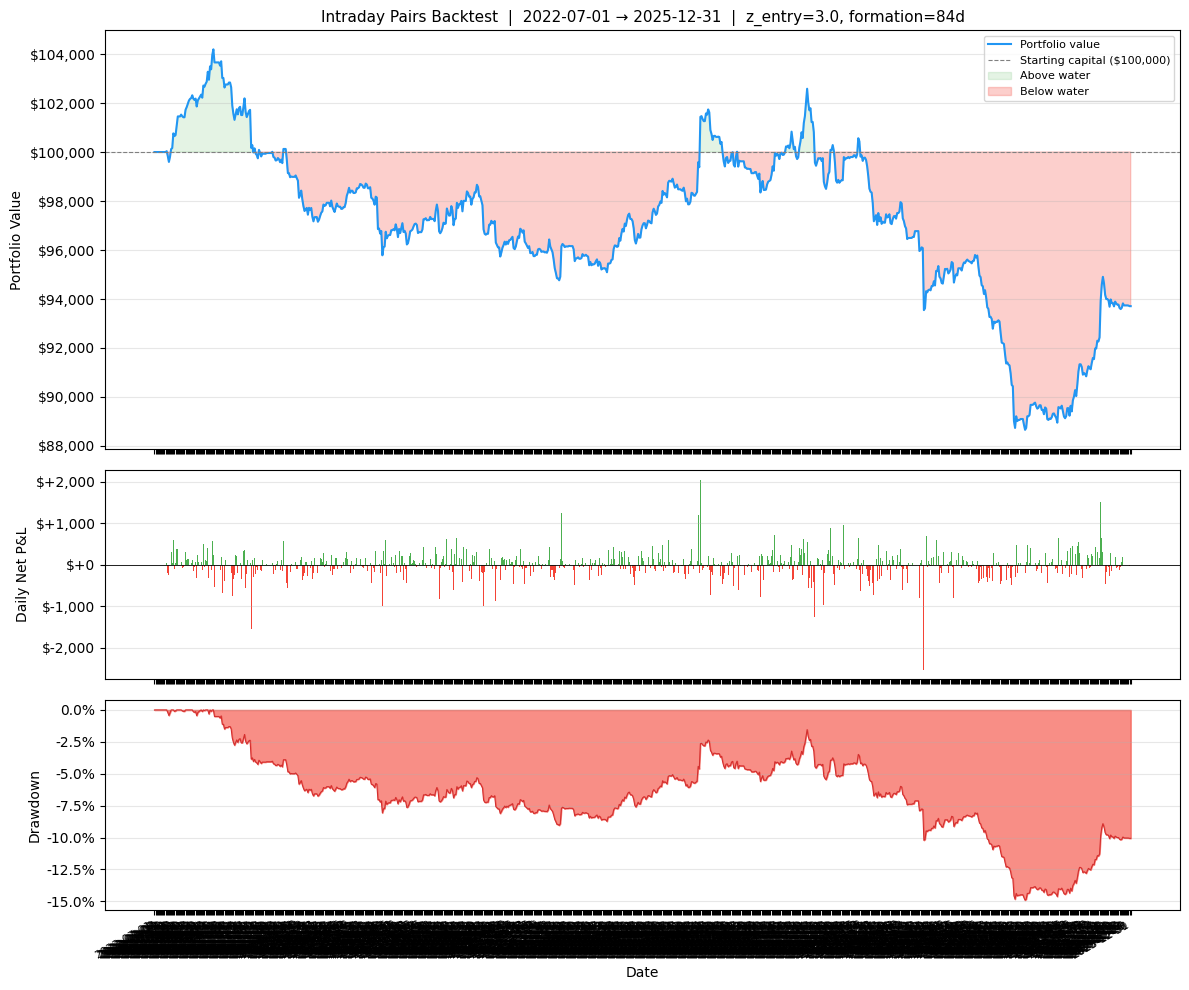

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1.5, 1.5]})

dates = daily_pnl_df["date"].to_list()
portfolio_values = daily_pnl_df["portfolio_value"].to_numpy()
net_pnls = daily_pnl_df["net_pnl"].to_numpy()
drawdowns_pct = drawdowns * 100

# ── Panel 1: Equity curve ──────────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(dates, portfolio_values, color="#2196F3", linewidth=1.5, label="Portfolio value")
ax1.axhline(capital, color="grey", linewidth=0.8, linestyle="--", label=f"Starting capital (${capital:,.0f})")
ax1.fill_between(dates, capital, portfolio_values,
                  where=(np.array(portfolio_values) >= capital),
                  alpha=0.15, color="#4CAF50", label="Above water")
ax1.fill_between(dates, capital, portfolio_values,
                  where=(np.array(portfolio_values) < capital),
                  alpha=0.25, color="#F44336", label="Below water")
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax1.set_ylabel("Portfolio Value")
ax1.set_title(
    f"Intraday Pairs Backtest  |  "
    f"{BACKTEST_PARAMS['start_date']} → {BACKTEST_PARAMS['end_date']}  |  "
    f"z_entry={BACKTEST_PARAMS['z_entry']}, formation={BACKTEST_PARAMS['rolling_window_days']}d",
    fontsize=11,
)
ax1.legend(fontsize=8)
ax1.grid(axis="y", alpha=0.3)

# ── Panel 2: Daily net P&L bar chart ──────────────────────────────────────
ax2 = axes[1]
colors = ["#4CAF50" if v >= 0 else "#F44336" for v in net_pnls]
ax2.bar(dates, net_pnls, color=colors, width=0.8)
ax2.axhline(0, color="black", linewidth=0.6)
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:+,.0f}"))
ax2.set_ylabel("Daily Net P&L")
ax2.grid(axis="y", alpha=0.3)

# ── Panel 3: Drawdown ─────────────────────────────────────────────────────
ax3 = axes[2]
ax3.fill_between(dates, drawdowns_pct, 0, color="#F44336", alpha=0.6)
ax3.plot(dates, drawdowns_pct, color="#D32F2F", linewidth=0.8)
ax3.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax3.set_ylabel("Drawdown")
ax3.set_xlabel("Date")
ax3.grid(axis="y", alpha=0.3)

# rotate x-tick labels
for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)

plt.tight_layout()
plt.show()

## 4. P&L Distributions

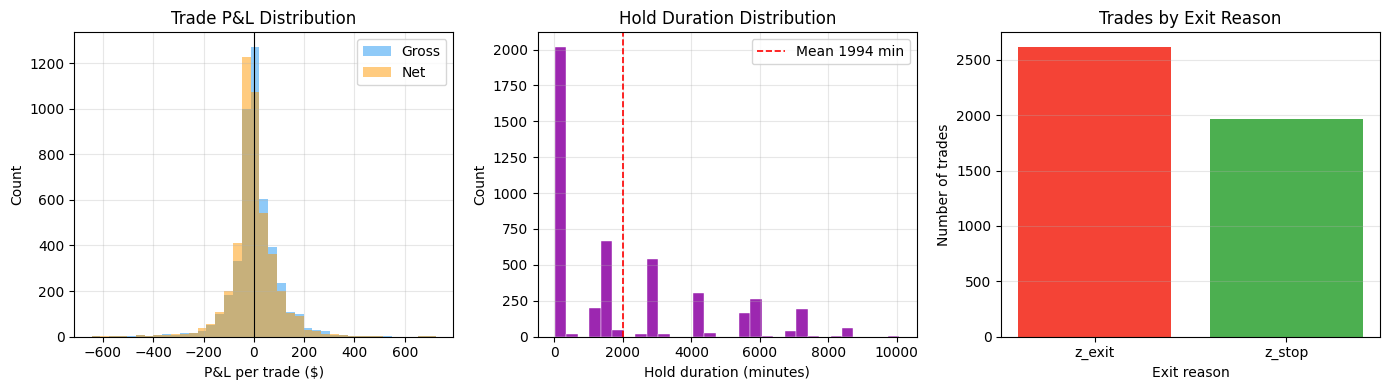

In [19]:
if len(trades_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # ── Gross vs Net P&L per trade ────────────────────────────────────────
    ax = axes[0]
    gross = trades_df["gross_pnl"].to_numpy()
    net = trades_df["net_pnl"].to_numpy()
    bins = np.linspace(min(gross.min(), net.min()), max(gross.max(), net.max()), 40)
    ax.hist(gross, bins=bins, alpha=0.5, color="#2196F3", label="Gross")
    ax.hist(net,   bins=bins, alpha=0.5, color="#FF9800", label="Net")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("P&L per trade ($)")
    ax.set_ylabel("Count")
    ax.set_title("Trade P&L Distribution")
    ax.legend()
    ax.grid(alpha=0.3)

    # ── Hold duration ─────────────────────────────────────────────────────
    ax = axes[1]
    hold_mins = (trades_df["exit_time"] - trades_df["entry_time"]).dt.total_minutes().to_numpy()
    ax.hist(hold_mins, bins=30, color="#9C27B0", edgecolor="white", linewidth=0.3)
    ax.axvline(float(np.mean(hold_mins)), color="red", linewidth=1.2,
               linestyle="--", label=f"Mean {np.mean(hold_mins):.0f} min")
    ax.set_xlabel("Hold duration (minutes)")
    ax.set_ylabel("Count")
    ax.set_title("Hold Duration Distribution")
    ax.legend()
    ax.grid(alpha=0.3)

    # ── Exit reason breakdown ─────────────────────────────────────────────
    ax = axes[2]
    reasons = trades_df.group_by("exit_reason").agg(pl.len().alias("n")).sort("exit_reason")
    ax.bar(reasons["exit_reason"].to_list(), reasons["n"].to_list(),
           color=["#F44336", "#4CAF50"])
    ax.set_xlabel("Exit reason")
    ax.set_ylabel("Number of trades")
    ax.set_title("Trades by Exit Reason")
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No trades to plot.")

## 5. Win Rate by Direction and Exit Reason

In [20]:
if len(trades_df) > 0:
    summary = (
        trades_df
        .with_columns(pl.when(pl.col("net_pnl") > 0).then(1).otherwise(0).alias("win"))
        .group_by(["direction", "exit_reason"])
        .agg(
            pl.col("win").mean().alias("win_rate"),
            pl.col("net_pnl").mean().alias("avg_net_pnl"),
            pl.col("gross_pnl").mean().alias("avg_gross_pnl"),
            pl.len().alias("n_trades"),
        )
        .sort(["direction", "exit_reason"])
    )
    print("Win rate and avg P&L by direction × exit reason:")
    print(summary.to_pandas().to_string(index=False))

    print()

    # Monthly P&L
    monthly = (
        daily_pnl_df
        .with_columns(pl.col("date").str.slice(0, 7).alias("month"))
        .group_by("month")
        .agg(
            pl.col("net_pnl").sum().alias("net_pnl"),
            pl.col("gross_pnl").sum().alias("gross_pnl"),
            pl.col("n_trades").sum().alias("n_trades"),
        )
        .sort("month")
    )
    print("Monthly P&L summary:")
    print(monthly.to_pandas().to_string(index=False))

Win rate and avg P&L by direction × exit reason:
 direction exit_reason  win_rate  avg_net_pnl  avg_gross_pnl  n_trades
        -1      z_exit  0.581979    15.471069      23.542378      1354
        -1      z_stop  0.218053   -21.511899     -13.855551       986
         1      z_exit  0.577532    17.114489      25.525911      1264
         1      z_stop  0.208376   -28.255466     -20.011720       979

Monthly P&L summary:
  month      net_pnl    gross_pnl  n_trades
2022-07   693.158421  1487.001142        86
2022-08  1649.068007  2358.293562        69
2022-09   291.118974  1034.807233        77
2022-10 -1090.942880    19.691962       129
2022-11 -1582.756636 -1241.281498        40
2022-12  -973.291662  -392.148859        60
2023-01 -1641.461387  -651.992578       119
2023-02   444.317594  1341.946803       113
2023-03   754.435618  1205.690195        52
2023-04 -2403.693335  -841.779703       201
2023-05   349.046214  1307.323158       110
2023-06   780.167766  1335.849108        70
20

## 6. Monthly Returns Heatmap

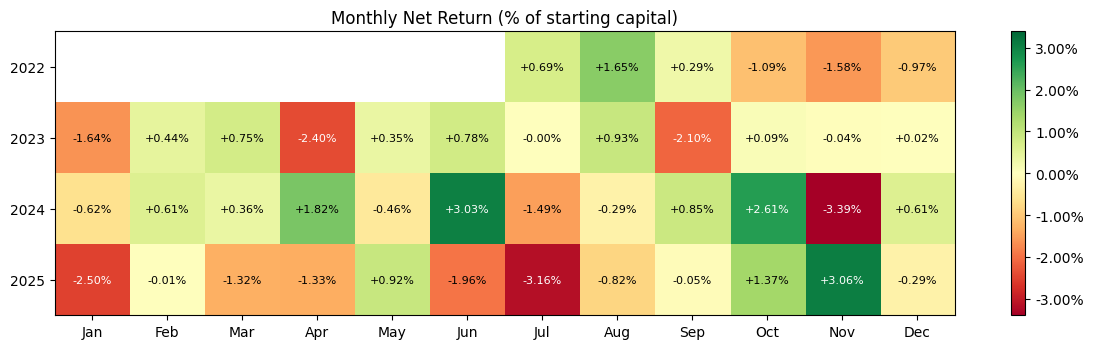

In [21]:
# Compute monthly net return (% of starting capital) for heatmap
if len(daily_pnl_df) > 0:
    monthly_ret = (
        daily_pnl_df
        .with_columns(
            pl.col("date").str.slice(0, 4).alias("year"),
            pl.col("date").str.slice(5, 2).alias("month"),
        )
        .group_by(["year", "month"])
        .agg(pl.col("net_pnl").sum().alias("net_pnl"))
        .sort(["year", "month"])
        .with_columns(
            (pl.col("net_pnl") / capital * 100).alias("return_pct")
        )
    )

    years  = sorted(monthly_ret["year"].unique().to_list())
    months = [f"{m:02d}" for m in range(1, 13)]
    month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"]

    grid = np.full((len(years), 12), np.nan)
    for row in monthly_ret.iter_rows(named=True):
        yi = years.index(row["year"])
        mi = int(row["month"]) - 1
        grid[yi, mi] = row["return_pct"]

    fig, ax = plt.subplots(figsize=(12, max(2, len(years) * 0.9)))
    vmax = np.nanmax(np.abs(grid))
    im = ax.imshow(grid, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")

    ax.set_xticks(range(12))
    ax.set_xticklabels(month_labels)
    ax.set_yticks(range(len(years)))
    ax.set_yticklabels(years)
    ax.set_title("Monthly Net Return (% of starting capital)")
    plt.colorbar(im, ax=ax, format="%.2f%%")

    for yi in range(len(years)):
        for mi in range(12):
            val = grid[yi, mi]
            if not np.isnan(val):
                ax.text(mi, yi, f"{val:+.2f}%", ha="center", va="center", fontsize=8,
                        color="black" if abs(val) < vmax * 0.6 else "white")

    plt.tight_layout()
    plt.show()

## 7. Sample Trade Log

In [22]:
if len(trades_df) > 0:
    sample = (
        trades_df
        .sort("entry_time")
        .select([
            "entry_time", "exit_time", "ticker_a", "ticker_b",
            "direction", "gross_pnl", "transaction_cost", "net_pnl", "exit_reason",
        ])
        .head(20)
    )
    print("First 20 trades (sorted by entry time):")
    print(sample.to_pandas().to_string(index=False))
else:
    print("No trades recorded.")

First 20 trades (sorted by entry time):
         entry_time           exit_time ticker_a ticker_b  direction  gross_pnl  transaction_cost    net_pnl exit_reason
2022-07-18 09:45:00 2022-07-19 09:45:00      XOM      SLB         -1  31.085467          7.071926  24.013541      z_exit
2022-07-18 09:45:00 2022-07-19 09:45:00     NVDA     INTC         -1 113.489655          9.931653 103.558002      z_exit
2022-07-18 09:45:00 2022-07-20 09:45:00       BA      MMM         -1 -39.009245          5.071239 -44.080484      z_exit
2022-07-18 10:00:00 2022-07-20 09:45:00      AEP      SRE          1 -74.034169          8.697164 -82.731332      z_exit
2022-07-19 11:00:00 2022-07-19 11:45:00      JNJ      TMO          1 -41.782378          6.514852 -48.297231      z_stop
2022-07-19 12:00:00 2022-07-19 12:15:00      JNJ      TMO          1  -0.013501          6.546152  -6.559653      z_stop
2022-07-19 12:00:00 2022-07-20 09:45:00      JNJ      PFE          1 -47.182565          5.999072 -53.181638     